# MLDoctor - Case2

For an automated retail kiosk that recommends a new look based on a user’s current appearance, the development team developed a classifier to detect whether an individual is wearing eyeglasses, enabling the system to suggest suitable frame styles as part of the recommendation. During internal “Lab Phase” testing, the model achieved near-perfect accuracy on the company’s validation set. Engineers also observed that its performance remained stable across different lighting conditions and head poses. However, within weeks of deployment, the results from the kiosks were puzzling. While the model worked reliably for some users, its accuracy dropped significantly for others. Even more confusingly, these errors occurred in clear, well-lit images similar to those used during internal testing. Please elaborate on the identified problem, explain how it was identified, and provide a recommended solution.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import torch
from sklearn.metrics import ConfusionMatrixDisplay
from utils import audit_utils

In [2]:
device = audit_utils.setup_env()

internal_path = 'Case2Dataset/test_internal'
external_path = 'Case2Dataset/test_external'

test_internal_loader, test_external_loader, test_internal_dataset, test_external_dataset = audit_utils.get_dataloaders(
    internal_path, external_path, batch_size=16, num_workers=1
)

Using device: cuda:0


Class mapping: {'negative': 0, 'positive': 1}


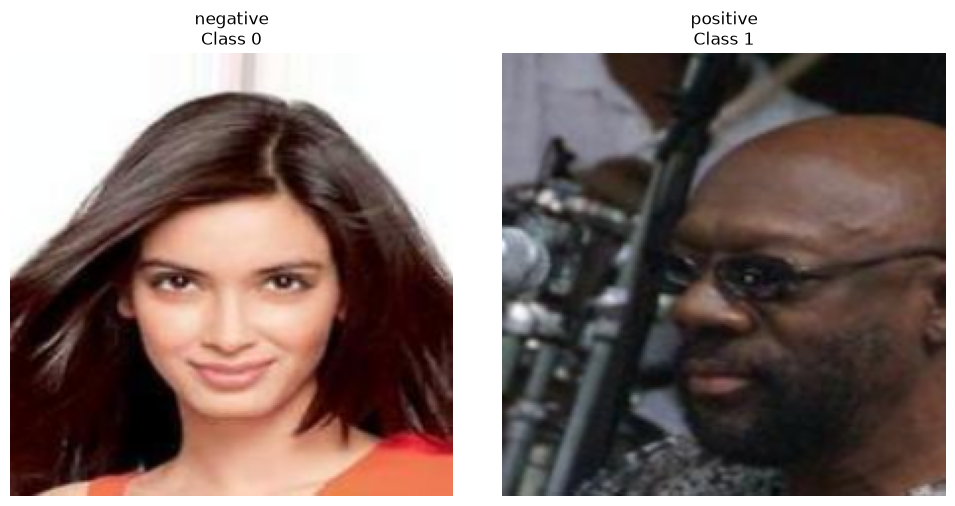

In [3]:
# Check class names and corresponding indices
print("Class mapping:",test_internal_dataset.class_to_idx)

# Display one sample image from each class
fig,axes=plt.subplots(1,len(test_internal_dataset.classes),figsize=(10,5))

for class_idx,class_name in enumerate(test_internal_dataset.classes):

    # Find the first sample belonging to this class
    sample_idx=test_internal_dataset.targets.index(class_idx)
    image,label=test_internal_dataset[sample_idx]

    # Reverse ImageNet normalization for visualization
    image=image.cpu().numpy().transpose(1,2,0)
    image=image*np.array(audit_utils.imagenet_stds)+np.array(audit_utils.imagenet_means)
    image=np.clip(image,0,1)

    # Display the sample image
    axes[class_idx].imshow(image)
    axes[class_idx].set_title(f"{class_name}\nClass {class_idx}")
    axes[class_idx].axis("off")

plt.tight_layout()

In [4]:
# Load the model
resnet_frozen = audit_utils.setup_model(2, "resnet_frozen_best_case2.pth", device)
print(resnet_frozen)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_sta

In [5]:
all_predictions, all_labels = audit_utils.evaluate_model(resnet_frozen, test_internal_loader, test_external_loader, device)

for split in ['internal', 'external']:
    predicted_classes = np.argmax(all_predictions[split], axis=1)
    accuracy = (predicted_classes == all_labels[split]).mean()
    print(f"{split} set - Accuracy: {accuracy:.3f}")

Evaluating on external set: 100%|██████████| 19/19 [00:00<00:00, 28.48it/s]

internal set - Accuracy: 0.987
external set - Accuracy: 0.710


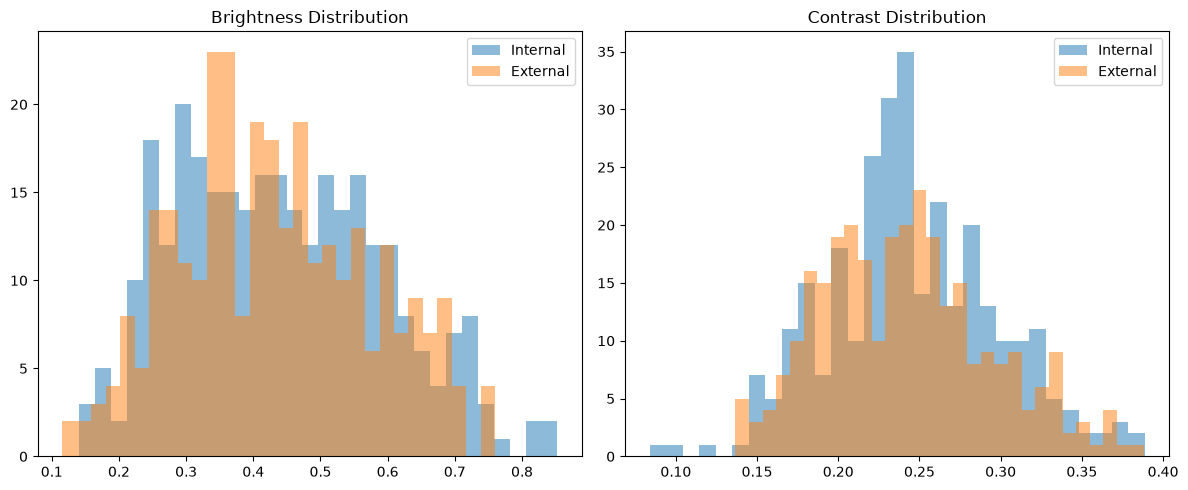

In [6]:
# Quantitative Dataset Comparison
audit_utils.plot_image_stats(test_internal_dataset, test_external_dataset, save_prefix='plot/case2_')


===== INTERNAL SET =====
Accuracy : 0.987
Precision: 1.000
Recall   : 0.973
F1-score : 0.986


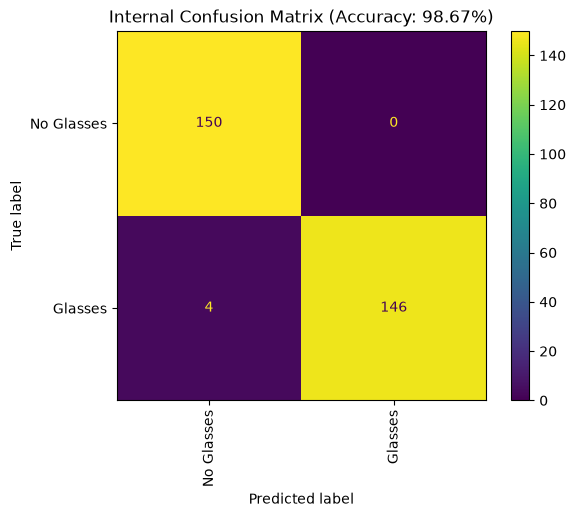

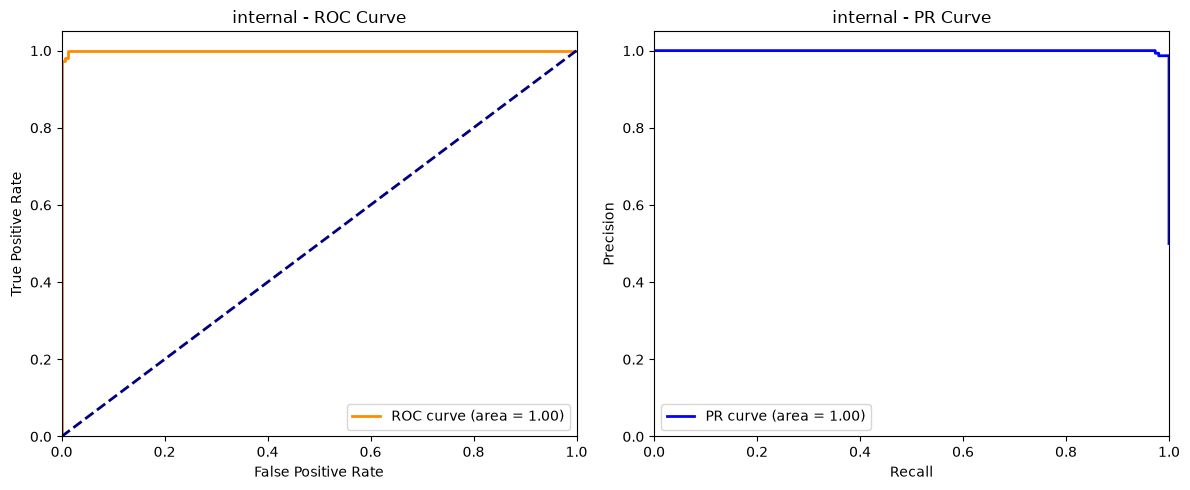


===== EXTERNAL SET =====
Accuracy : 0.710
Precision: 0.756
Recall   : 0.620
F1-score : 0.681


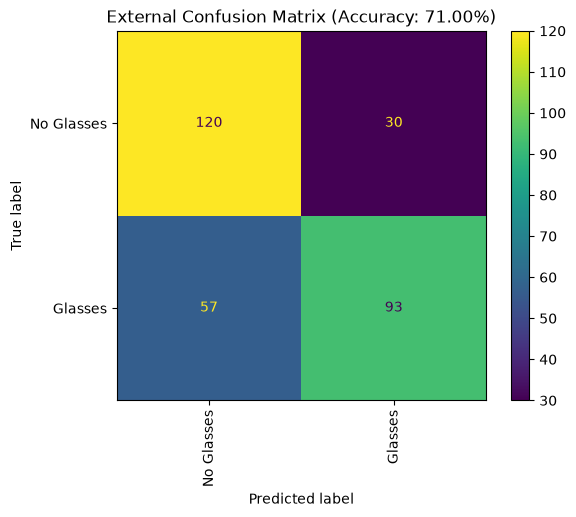

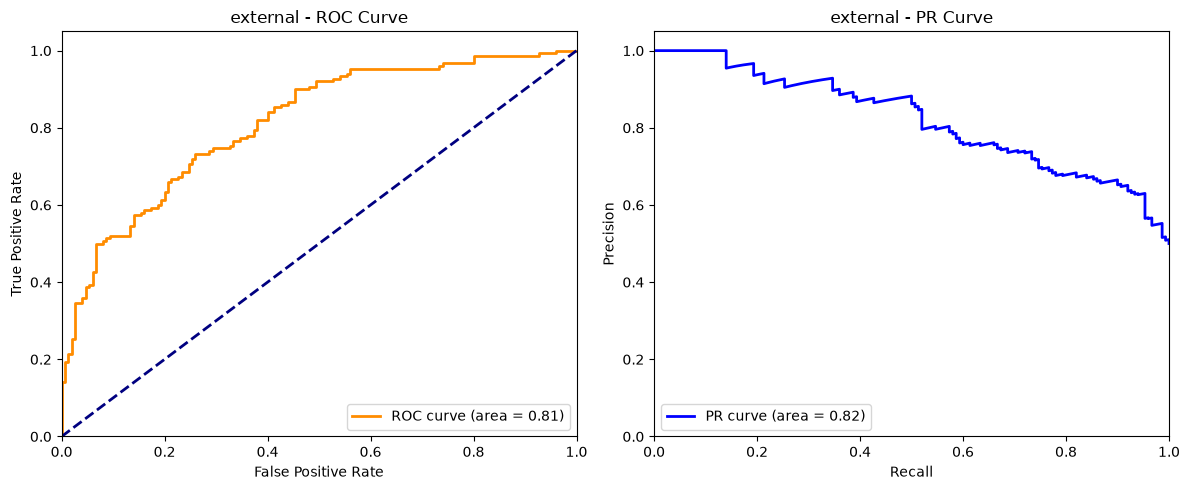

In [7]:
threshold = 0.5
for split in ['internal', 'external']:
    labels = all_labels[split]
    probs_glasses = all_predictions[split][:, 1]
    preds = probs_glasses >= threshold

    accuracy = (preds == labels.astype(bool)).mean()
    precision, recall, f1 = audit_utils.compute_metrics(labels, probs_glasses, threshold=threshold)

    print(f"\n===== {split.upper()} SET =====")
    print(f"Accuracy : {accuracy:.3f}")
    print(f"Precision: {precision:.3f}")
    print(f"Recall   : {recall:.3f}")
    print(f"F1-score : {f1:.3f}")

    # Plot confusion matrix
    ConfusionMatrixDisplay.from_predictions(
        labels, preds, display_labels=['No Glasses', 'Glasses'], xticks_rotation='vertical'
    )
    plt.title(f'{split.capitalize()} Confusion Matrix (Accuracy: {accuracy * 100:.2f}%)')
    plt.savefig(f'plot/case2_cm_{split}.png')
    plt.show()
    
    # Plot ROC and PR curves
    audit_utils.plot_roc_pr_curves(labels, probs_glasses, split, save_prefix='plot/case2_')

Accuracy decreased substantially from 98.7% on the internal test set to 71.0% on the external test set. False positives increased from 0 to 30, while false negatives increased from 4 to 57.

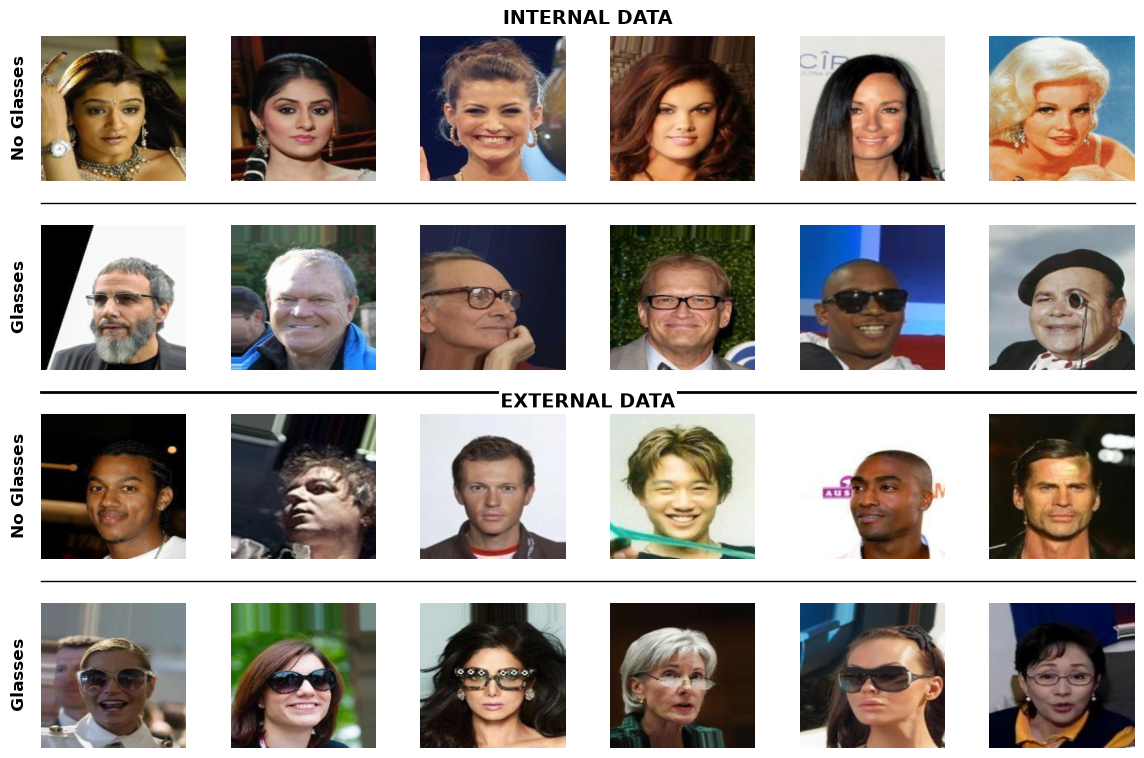

In [8]:
# Identify samples by actual class
internal_labels=all_labels['internal']
external_labels=all_labels['external']

internal_no_glasses=np.where(internal_labels==0)[0]
internal_glasses=np.where(internal_labels==1)[0]
external_no_glasses=np.where(external_labels==0)[0]
external_glasses=np.where(external_labels==1)[0]

# Select 6 samples from each group
np.random.seed(0)
selected_internal_no_glasses=np.random.choice(internal_no_glasses,6,replace=False)
selected_internal_glasses=np.random.choice(internal_glasses,6,replace=False)
selected_external_no_glasses=np.random.choice(external_no_glasses,6,replace=False)
selected_external_glasses=np.random.choice(external_glasses,6,replace=False)

# Denormalize images for visualization
def denormalize_image(image):
    image=image.numpy().transpose(1,2,0)
    image=image*np.array(audit_utils.imagenet_stds)+np.array(audit_utils.imagenet_means)
    return np.clip(image,0,1)

# Define groups
groups=[
    (test_internal_dataset,selected_internal_no_glasses,'No Glasses'),
    (test_internal_dataset,selected_internal_glasses,'Glasses'),
    (test_external_dataset,selected_external_no_glasses,'No Glasses'),
    (test_external_dataset,selected_external_glasses,'Glasses')
]

# Create figure
fig,axes=plt.subplots(4,6,figsize=(13,8))

for row,(dataset,indices,class_name) in enumerate(groups):
    for col,idx in enumerate(indices):
        image,label=dataset[idx]
        axes[row,col].imshow(denormalize_image(image))

        # Hide ticks but keep y-axis label visible
        axes[row,col].set_xticks([])
        axes[row,col].set_yticks([])
        
        # Hide plot borders
        for spine in axes[row,col].spines.values():
            spine.set_visible(False)

    # Show actual class on y-axis
    axes[row,0].set_ylabel(
        class_name,
        fontsize=12,
        fontweight='bold',
        labelpad=10
    )

# Reduce empty space
plt.subplots_adjust(left=0.11,right=0.98,top=0.93,bottom=0.04,hspace=0.30,wspace=0.04)
fig.canvas.draw()

# Plot boundaries
x_left=axes[0,0].get_position().x0
x_right=axes[0,5].get_position().x1

# INTERNAL DATA title
y_internal_title=axes[0,0].get_position().y1+0.015
fig.text(
    (x_left+x_right)/2,
    y_internal_title,
    'INTERNAL DATA',
    ha='center',
    fontsize=14,
    fontweight='bold'
)

# Divider between No Glasses and Glasses
y_internal=(axes[0,0].get_position().y0+axes[1,0].get_position().y1)/2
fig.add_artist(plt.Line2D(
    [x_left,x_right],
    [y_internal,y_internal],
    transform=fig.transFigure,
    color='black',
    linewidth=1
))

# Divider between Internal and External
y_dataset=(axes[1,0].get_position().y0+axes[2,0].get_position().y1)/2
fig.add_artist(plt.Line2D(
    [x_left,x_right],
    [y_dataset,y_dataset],
    transform=fig.transFigure,
    color='black',
    linewidth=2
))

# EXTERNAL DATA title
y_external_title=axes[2,0].get_position().y1+0.008
fig.text(
    (x_left+x_right)/2,
    y_external_title,
    'EXTERNAL DATA',
    ha='center',
    fontsize=14,
    fontweight='bold',
    bbox=dict(facecolor='white',edgecolor='none',pad=1)
)

# Divider between No Glasses and Glasses
y_external=(axes[2,0].get_position().y0+axes[3,0].get_position().y1)/2
fig.add_artist(plt.Line2D(
    [x_left,x_right],
    [y_external,y_external],
    transform=fig.transFigure,
    color='black',
    linewidth=1
))



Visual inspection revealed a strong spurious correlation between the eyeglasses label and gender-associated appearance in the sampled images. In the internal data, No Glasses samples were female-presenting while Glasses samples were male-presenting. In the external data, this relationship was reversed, with No Glasses samples being male-presenting and Glasses samples being female-presenting. This distribution shift suggests that the model may have learned gender-associated facial features as a shortcut for eyeglasses classification rather than relying exclusively on the presence of eyeglasses.

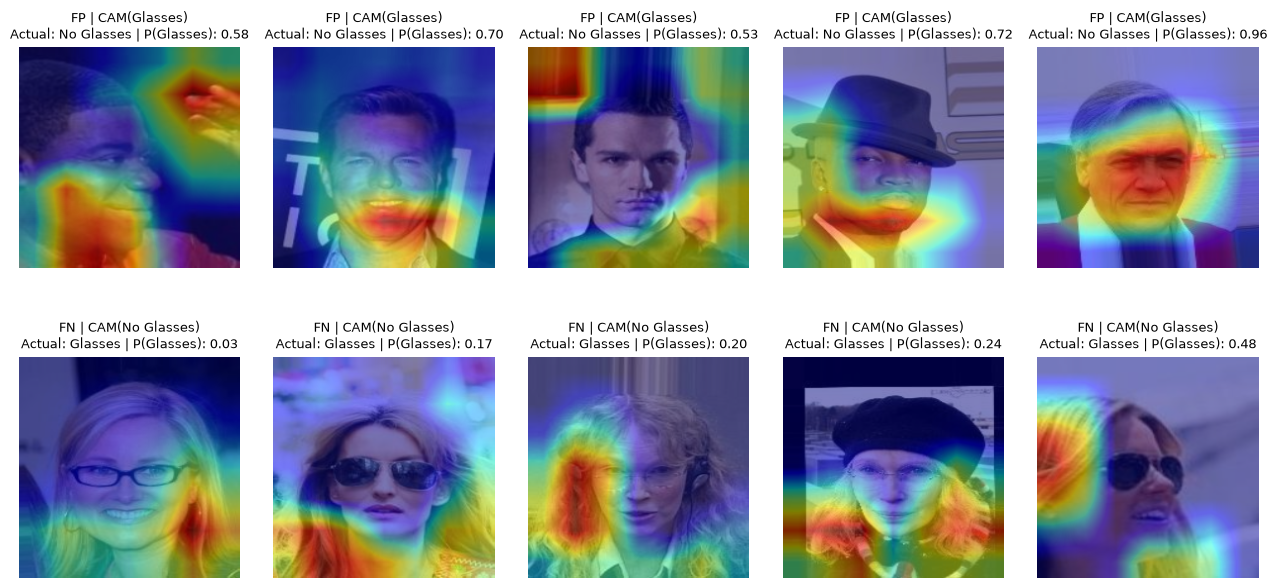

In [9]:
# Get external labels and predicted probabilities
labels = all_labels['external']
probs_glasses = all_predictions['external'][:,1]
preds = probs_glasses >= 0.5

fp_indices = np.where((labels == 0) & (preds == 1))[0]
fn_indices = np.where((labels == 1) & (preds == 0))[0]

np.random.seed(10)
selected_fp = np.random.choice(fp_indices, 5, replace=False)
selected_fn = np.random.choice(fn_indices, 5, replace=False)

# CAM Implementation
activation = {}

def get_activation(name):
    def hook(model, input, output):
        activation[name] = output.detach()
    return hook

target_layer = resnet_frozen.layer4[1].conv2
hook_handle = target_layer.register_forward_hook(get_activation('layer4_conv2'))

cam_groups = [
    ('FP', selected_fp),
    ('FN', selected_fn)
]

resnet_frozen.eval()
fig, axes = plt.subplots(2, 5, figsize=(16, 7))

with torch.no_grad():
    for row, (result, indices) in enumerate(cam_groups):
        for col, idx in enumerate(indices):
            x, y = test_external_dataset[idx]
            x = x.to(device).unsqueeze(0)

            # Run inference
            output = resnet_frozen(x)
            pred = torch.argmax(output, dim=1).item()
            prob_glasses = torch.softmax(output, dim=1)[0, 1].item()

            # CAM computation using audit_utils
            conv_feature_map = activation['layer4_conv2'][0]
            fc_weights = resnet_frozen.fc.weight[pred].detach()
            cam = audit_utils.compute_cam(conv_feature_map, fc_weights, image_size=(x.shape[2], x.shape[3]))

            x_display = audit_utils.denormalize_image(x.squeeze(0).cpu())
            actual = 'Glasses' if y == 1 else 'No Glasses'
            predicted = 'Glasses' if pred == 1 else 'No Glasses'

            axes[row, col].imshow(x_display)
            axes[row, col].imshow(cam, alpha=0.5, cmap='jet')
            axes[row, col].set_title(
                f'{result} | CAM({predicted})\n'
                f'Actual: {actual} | P(Glasses): {prob_glasses:.2f}',
                fontsize=9
            )
            axes[row, col].axis('off')

axes[0,0].set_ylabel('FP\nNo Glasses -> Glasses', fontsize=11, labelpad=10)
axes[1,0].set_ylabel('FN\nGlasses -> No Glasses', fontsize=11, labelpad=10)

plt.subplots_adjust(hspace=0.35, wspace=0.15)
plt.savefig('plot/case2_cam.png')
plt.show()

hook_handle.remove()

## Evaluation Processing Reasoning

We evaluate the classification metrics and ROC/PR curves to confirm the performance disparity between the internal and external test sets. Since the external dataset also consists of well-lit images (ruling out lighting/camera quality drops), we must investigate what specific subgroups are failing. We use CAM on False Positives and False Negatives to determine if the model is ignoring the eye region and instead relying on other demographic or facial features.

## Diagnosis

A suspected proxy reliance on gender-associated appearance is suggested as a potential source of the deployment
performance disparity. Gender-associated characteristics were differently represented across the Glasses and No Glasses labels in the internal and external datasets, raising concerns that the classifier relied on gender-related rather than eyeglass-specific features. 

## Evidence

1. **Performance Disparity**: Compared with the internal dataset, accuracy decreased from 98.7% to 71.0% and ROC-AUC from approximately 1.00 to 0.81 on the external dataset. False positives increased from 0 to 30 and false negatives from 4 to 57, indicating reduced discrimination and increased errors in both directions.

2. **Dataset Composition**: Visual inspection of the sampled images revealed contrasting gender-associated class compositions. In the internal data, No Glasses samples were female-presenting and Glasses samples were male-presenting. In the external data, No Glasses samples were male-presenting and Glasses samples were female-presenting. This reversal supports the suspected reliance on gender-associated characteristics that do not consistently represent the target attribute across datasets

2. **CAM Saliency Maps**: CAMs of misclassified predictions showed that the strongest activations were often not concentrated on the eyeglass region. FNs, involving female-presenting individuals with glasses, frequently showed strong activation around the hair, while FPs, involving male-presenting individuals without glasses, exhibited less consistent activation across the lower face, facial contours, and surrounding regions. This pattern is consistent with the suspected gender-associated reliance, as CAMs showed activation on appearance-related regions beyond the target eyeglass region.

## Recommendations

1. **Dataset de-biasing**: Audit the training dataset for demographic imbalances. Ensure an equal representation of subgroups (e.g., gender, race, makeup usage) across both the 'Glasses' and 'No Glasses' classes to break the spurious correlation.

2. **Feature disentanglement / Adversarial training**: Employ adversarial training techniques to penalize the model for learning protected attributes (like gender or race), forcing it to rely only on the glasses.

3. **Spatial Priors**: Similar to Case 1, use a landmark detector to crop heavily around the eye region, preventing the model from utilizing hair or jawline features.